In [1]:
import ROOT
import os
import matplotlib.pyplot as plt
import numpy as np
import os
from pathlib import Path
import uproot
import awkward as ak

# MC - contains Truth and MasterAnaDev
file = "/scratch/MINERvA/raw_data/MediumEnergy_FHC_StandardMC_Playlist/1A/MasterAnaDev_mc_AnaTuple_run00110000_Playlist.root"


/usr/local/lib/python3.10/dist-packages/ROOT/__init__.py:5: UserWarning: 
This distribution of ROOT is in alpha stage. Feedback is welcome and appreciated. Feel free to reach out to the user forum for questions and general feedback at https://root-forum.cern.ch or to submit an issue at https://github.com/root-project/root/issues. Do not rely on this distribution for production purposes.

  warnings.warn(
/usr/local/lib/python3.10/dist-packages/cppyy/__init__.py:374: UserWarning: CPyCppyy API not found (tried: /usr/include/site/python3.10); set CPPYY_API_PATH envar to the 'CPyCppyy' API directory to fix
  warnings.warn("CPyCppyy API not found (tried: %s); "


In [2]:
with uproot.open(file) as uf:
    master_ana_dev = uf["MasterAnaDev"]
    #truth = uf["Truth"] # open latest cycle of Truth
    arr = master_ana_dev["prong_part_pos"].array()

In [3]:
# flatten the arr
arr_flat = ak.flatten(arr).to_numpy()
np.isnan(arr_flat[:, 0]).sum()

2

In [4]:
for key in master_ana_dev.keys():
    print(key)


eventID
physEvtNum
n_hyps
processType
primaryPart
n_slices
slice_numbers
shared_slice
vtx
vtxErr
E
reco_vertex_batch
found_truth
phys_front_activity
phys_energy_in_road_upstream_is_rockmuon_consistent
rock_muons_removed
minos_track_match
minos_stub_match
unknown_helicity
minos_track_inside_partial_plane
prim_vtx_has_misassigned_track_direction
prim_vtx_has_broken_track
pass_MasterAnaDev
hasVetoWall
VetoWalldigitsGood
VetoWall_extrapnowalls
VetoWall_extrapwall1
VetoWall_extrapwall2
VetoWall_extrapbothwalls
VetoWall_MuonTrkMatchToVETOwalloff
Cut_BlobDirectionBad
Cut_PreFilter_Pi0
EMLikeTrackMultiplicity
FailContainedProng
Good_Blobs
HasNoBackExitingTracks
HasNoVertexMismatch
HasTracks
ID_Hits_Post_Long
NeutronMaxClusters
NneutronClusters0
NneutronClusters1
NneutronClusters2
NneutronClusters3
PassNeutronMaxClusterCut
StartPointVertexMultiplicity
UpstreamInlineNClusters
UpstreamInlineNDigits
VertexTrackMultiplicity
VetoWall_NumberMatchToVeto
VetoWall_event_IsVeto
VetoWall_sixPush
anglescan

In [5]:
multiplicity = master_ana_dev["multiplicity"].array().to_numpy()

In [6]:
nprongs = master_ana_dev["n_prongs"].array().to_numpy()

In [7]:
(multiplicity == nprongs).mean()

0.9536524010534276

In [8]:
# Sanity check of the variables
# target: mc_incomingE

# MC: 
# mc_FSPartPx
# mc_FSPartPy
# mc_FSPartPz
# mc_FSPartE
# mc_nFSPart

# muons:
# muon_theta
# muon_phi
# muon_thetaX
# muon_thetaY
# muon_corrected_p

# prongs:
# prong_part_score
# prong_part_mass
# prong_part_charge
# prong_part_pid
# prong_part_E
# prong_part_pos

#MasterAnaDev_Blob<X,Y,Z,T,TPos>
#MasterAnaDev_BlobTotalE

# Read out the muon variables and print them for first 2 events

muon_theta = master_ana_dev["muon_theta"].array().to_numpy()
muon_phi = master_ana_dev["muon_phi"].array().to_numpy()
muon_thetaX = master_ana_dev["muon_thetaX"].array().to_numpy()
muon_thetaY = master_ana_dev["muon_thetaY"].array().to_numpy()
muon_corrected_p = master_ana_dev["muon_corrected_p"].array().to_numpy()
muon_psize = np.linalg.norm(muon_corrected_p, axis=1)
muon_theta_from_p = np.arccos(muon_corrected_p[:,2] / muon_psize)
muon_phi_from_p = np.arctan2(muon_thetaY, muon_thetaX)
muon_phi_from_pxy = np.arctan2(muon_corrected_p[:,2], muon_corrected_p[:,1])
muon_magnitude = np.linalg.norm(muon_corrected_p[:, :3], axis=1)
for i in range(2):
    print(f"Event {i}:")
    print(f"  muon_theta: {muon_theta[i]}")
    print(f"  muon_phi: {muon_phi[i]}")
    print(f"  muon_thetaX: {muon_thetaX[i]}")
    print(f"  muon_thetaY: {muon_thetaY[i]}")
    print(f"  muon_corrected_p: {muon_corrected_p[i]}")
    print(f"  muon_theta_from_p: {muon_theta_from_p[i]}")
    print(f"  muon_phi_from_p: {muon_phi_from_p[i]}")
    print(f"  muon_phi_from_pxy: {muon_phi_from_pxy[i]}")
    print(f"  muon_magnitude: {muon_magnitude[i]}")
    

Event 0:
  muon_theta: 0.11499511790266799
  muon_phi: 0.5181421501101529
  muon_thetaX: 0.10000889143106999
  muon_thetaY: 0.05714339089666122
  muon_corrected_p: [ 1130.81708459   -19.48972521 11287.85073861 11344.86073523]
  muon_theta_from_p: 0.7903893346299309
  muon_phi_from_p: 0.5191118387560504
  muon_phi_from_pxy: 1.572522935898237
  muon_magnitude: 11344.368709862945
Event 1:
  muon_theta: 0.10632033439172965
  muon_phi: -1.1775612103631294
  muon_thetaX: 0.04087110950860792
  muon_thetaY: -0.09825961941578645
  muon_corrected_p: [ 177.17437504 -681.25857007 4299.90620788 4358.42415001]
  muon_theta_from_p: 0.7985929141185187
  muon_phi_from_p: -1.1766158327479521
  muon_phi_from_pxy: 1.727925946210682
  muon_magnitude: 4357.143260788852


In [9]:
# save the MC truth particle four-vectors and PDGs into a compact matrix
mc_part = ak.zip({
    "px": master_ana_dev["mc_FSPartPx"].array(),
    "py": master_ana_dev["mc_FSPartPy"].array(),
    "pz": master_ana_dev["mc_FSPartPz"].array(),
    "E": master_ana_dev["mc_FSPartE"].array(),
    "pdg": master_ana_dev["mc_FSPartPDG"].array(),
})


In [10]:
# save the prong info 
reco_prongs = ak.zip({
    "score": master_ana_dev["prong_part_score"].array(),
    "mass": master_ana_dev["prong_part_mass"].array(),
    "charge": master_ana_dev["prong_part_charge"].array(),
    "pid": master_ana_dev["prong_part_pid"].array(),
    "E": master_ana_dev["prong_part_E"].array(),
    "pos": master_ana_dev["prong_part_pos"].array(),
})

In [11]:
# save the blob info
reco_blobs = ak.zip({
    "x": master_ana_dev["MasterAnaDev_BlobX"].array(),
    "y": master_ana_dev["MasterAnaDev_BlobY"].array(),
    "z": master_ana_dev["MasterAnaDev_BlobZ"].array(),
    "t": master_ana_dev["MasterAnaDev_BlobT"].array(),
    "tpos": master_ana_dev["MasterAnaDev_BlobTPos"].array(),
    "totalE": master_ana_dev["MasterAnaDev_BlobTotalE"].array(),
})


In [12]:

reco_muons = {
    "theta": master_ana_dev["muon_theta"].array().to_numpy(),
    "phi": master_ana_dev["muon_phi"].array().to_numpy(),
    "thetaX": master_ana_dev["muon_thetaX"].array().to_numpy(),
    "thetaY": master_ana_dev["muon_thetaY"].array().to_numpy(),
    "corrected_p": master_ana_dev["muon_corrected_p"].array().to_numpy(),
    "muon_fuzz_energy": master_ana_dev["muon_fuzz_energy"].array().to_numpy(),
    "muon_iso_blobs_energy": master_ana_dev["muon_iso_blobs_energy"].array().to_numpy(),
}
reco_muons["E"]  = reco_muons["corrected_p"][:, 3]
reco_muons["p"] = reco_muons["corrected_p"][:, :3]
reco_muons["psize"] = np.linalg.norm(reco_muons["p"], axis=1)
mask = reco_muons["corrected_p"][:, 0] != -999
reco_muons_theta_out = reco_muons["theta"][~mask]
reco_muons_phi_out = reco_muons["phi"][~mask]
# do the same for "muon_fuzz_energy", "muon_iso_blobs_energy"
muon_fuzz_energy_out = reco_muons["muon_fuzz_energy"][~mask]
muon_iso_blobs_energy_out = reco_muons["muon_iso_blobs_energy"][~mask]
reco_muons = {k: v[mask] for k, v in reco_muons.items()}
target = master_ana_dev["mc_incomingE"].array().to_numpy()
target = target[mask]

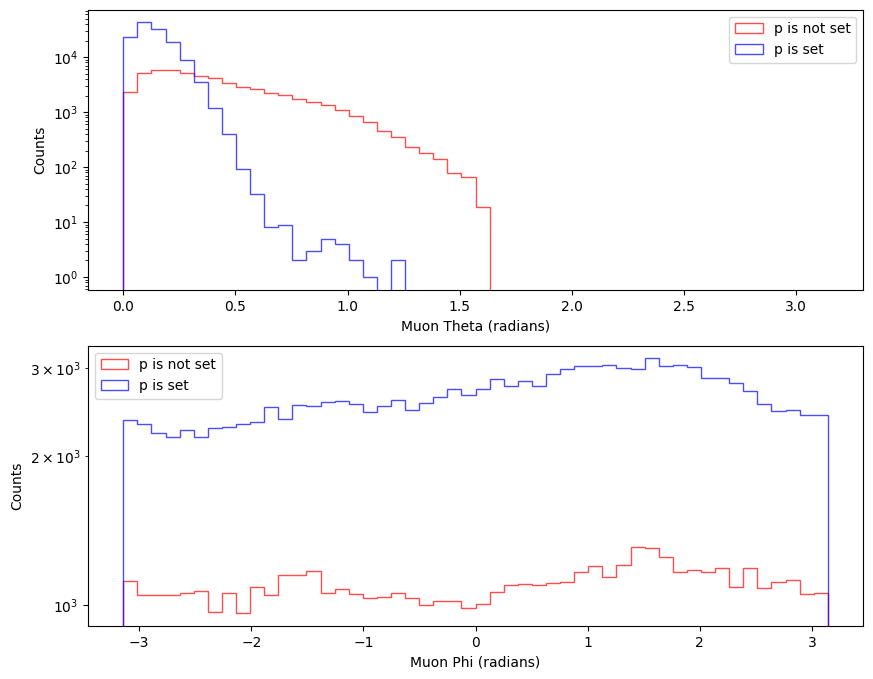

In [13]:
fig, ax = plt.subplots(2, 1, figsize=(10, 8))
 # plot histograms of reco_muons["theta"], reco_muons_theta_out for the first hiustogram; and sam efor phi for 2nd
ax[0].hist(reco_muons_theta_out, bins=50, range=(0, np.pi), alpha=0.7, color='r', histtype="step")
ax[0].hist(reco_muons["theta"], bins=50, range=(0, np.pi), alpha=0.7, color='b', histtype="step")
ax[0].set_xlabel("Muon Theta (radians)")
ax[0].set_ylabel("Counts")
ax[0].legend(["p is not set", "p is set"])
ax[0].set_yscale("log")
ax[1].hist(reco_muons_phi_out, bins=50, range=(-np.pi, np.pi), alpha=0.7, color='r', histtype="step")
ax[1].hist(reco_muons["phi"], bins=50, range=(-np.pi, np.pi), alpha=0.7, color='b', histtype="step")
ax[1].set_xlabel("Muon Phi (radians)")
ax[1].set_ylabel("Counts")
ax[1].legend(["p is not set", "p is set"])
ax[1].set_yscale("log")

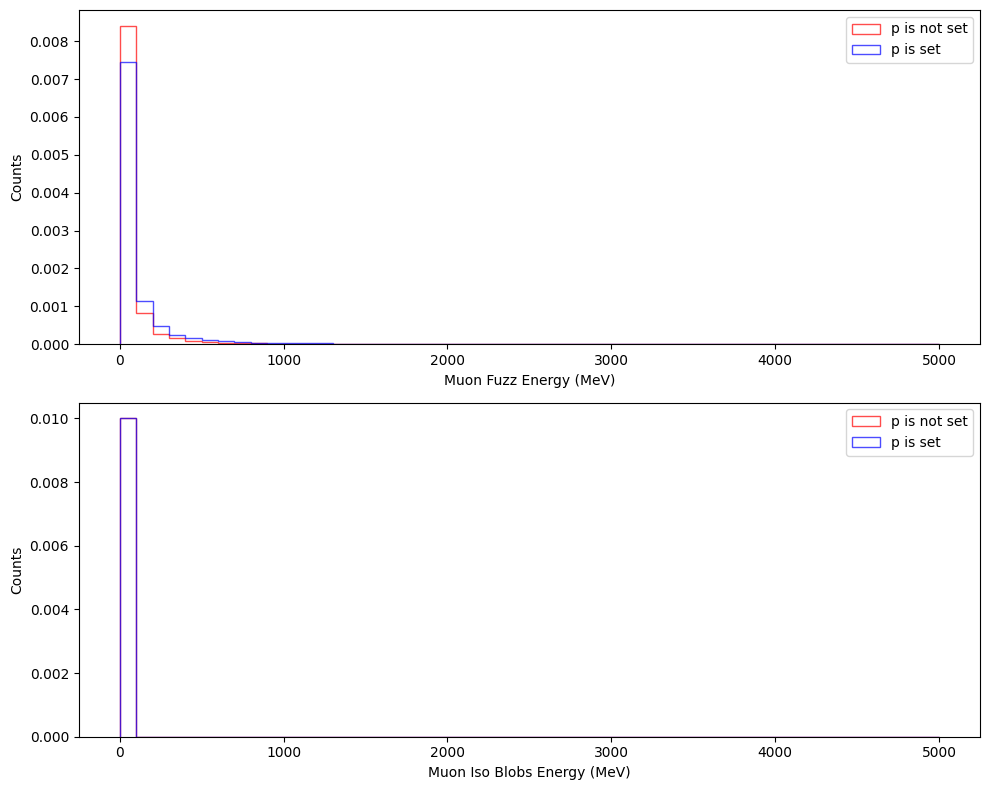

In [13]:
# similar plots for muon_fuzz_energy and muon_iso_blobs_energy
fig, ax = plt.subplots(2, 1, figsize=(10, 8))
 # plot histograms of muon_fuzz_energy_out, reco_muons["muon_fuzz_energy"] for the first hiustogram; and same for muon_iso_blobs_energy for 2nd
ax[0].hist(muon_fuzz_energy_out, bins=50, range=(0, 5000), alpha=0.7, color='r', histtype="step", density=True)
ax[0].hist(reco_muons["muon_fuzz_energy"], bins=50, range=(0, 5000), alpha=0.7, color='b', histtype="step", density=True)
ax[0].set_xlabel("Muon Fuzz Energy (MeV)")
ax[0].set_ylabel("Counts")
ax[0].legend(["p is not set", "p is set"])

ax[1].hist(muon_iso_blobs_energy_out, bins=50, range=(0, 5000), alpha=0.7, color='r', histtype="step", density=True)
ax[1].hist(reco_muons["muon_iso_blobs_energy"], bins=50, range=(0, 5000), alpha=0.7, color='b', histtype="step", density=True)
ax[1].set_xlabel("Muon Iso Blobs Energy (MeV)")
ax[1].set_ylabel("Counts")
ax[1].legend(["p is not set", "p is set"])

plt.tight_layout()
plt.show()

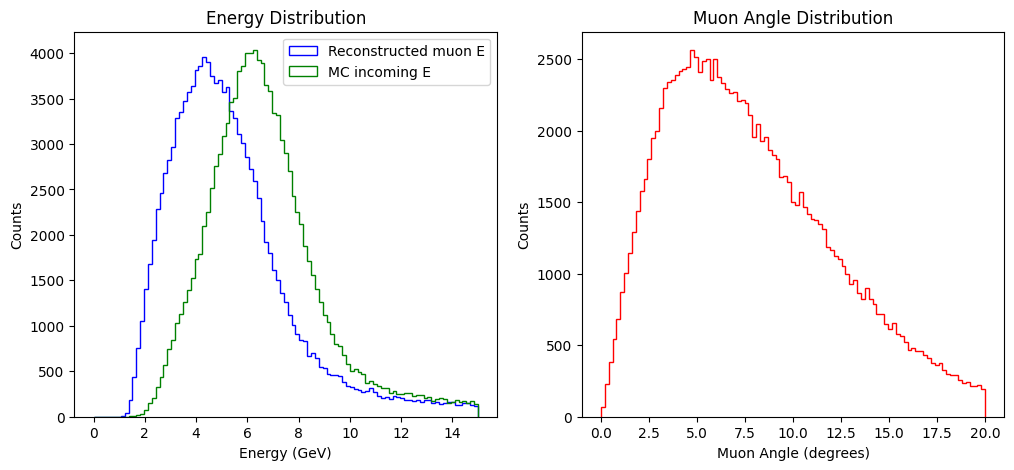

In [14]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax[0].hist(reco_muons["E"] / 1000, bins=np.linspace(0, 15, 100), histtype='step', color='blue', label="Reconstructed muon E")
ax[0].hist(target / 1000, bins=np.linspace(0, 15, 100), histtype='step', color='green', label="MC incoming E")
ax[0].set_xlabel("Energy (GeV)")
ax[0].set_ylabel("Counts")
ax[0].legend()
ax[0].set_title("Energy Distribution")
ax[1].hist(reco_muons["theta"] * (180/np.pi), bins=np.linspace(0, 20, 100), histtype='step', color='red')
ax[1].set_xlabel("Muon Angle (degrees)")
ax[1].set_ylabel("Counts")
ax[1].set_title("Muon Angle Distribution")
fig.show()

In [15]:
reco_muons["E"].min()

977.5633283797697

In [16]:
# compute magnitude of mc_FSPartPx, Py, Pz, and compare to mc_FSPartE
mc_part_magnitude = np.sqrt(mc_part.px**2 + mc_part.py**2 + mc_part.pz**2)
mc_part_E = mc_part.E
msquared = (mc_part_E**2 - mc_part_magnitude**2)
m = np.sqrt(msquared)

/usr/local/lib/python3.10/dist-packages/awkward/_nplikes/array_module.py:246: RuntimeWarning: invalid value encountered in sqrt
  return impl(*broadcasted_args, **(kwargs or {}))


In [17]:
np.sqrt(reco_muons["E"]**2-reco_muons["psize"]**2)

array([105.6583, 105.6583, 105.6583, ..., 105.6583, 105.6583, 105.6583])

In [18]:
mc_part.pdg

<Array [[-13, 2112, 2212, ..., -211, 2112], ...] type='186439 * var * int32'>

In [19]:
reco_prongs

<Array [[[{score: 1, ...}, ...], ...], ...] type='186439 * var * var * {sco...'>

In [20]:
reco_prongs.mass

<Array [[[106, 106, 106, 106], ...], ...] type='186439 * var * var * float64'>

In [21]:
reco_prongs.pid

<Array [[[3, 3, 3, 3], [8, ..., 8]], ...] type='186439 * var * var * int32'>

In [22]:
# print gamma1_E and gamma1_P
gamma1_E = reco_prongs.E[:, 0]
gamma1_P = np.linalg.norm(reco_prongs.pos[:, 0], axis=1)

In [23]:
g1np = gamma1_E.to_numpy()

In [24]:
g1np[:, 3]**2 - g1np[:, 0]**2 - g1np[:, 1]**2 - g1np[:, 2]**2


# why is the mass of gamma1 not zero?

array([1.11636764e+04, 1.11636764e+04, 1.11636764e+04, ...,
       1.00000000e+00, 1.00000000e+00, 1.11636764e+04])

In [25]:
g1np

array([[ 1129.10334423,   -19.46018875, 11270.74412999, 11327.66922103],
       [  177.17437504,  -681.25857007,  4299.90620788,  4358.42415001],
       [  485.74735937,  -519.84650531,  4910.80407548,  4963.19969681],
       ...,
       [  -47.8752438 ,   153.71731011,   366.95777576,   400.7244185 ],
       [ 1216.62586669,  1160.77659517,  1561.58456488,  2294.80460097],
       [ -523.01484441,  -896.18211085,  6445.18496064,  6529.03206888]])

In [26]:
# Check the prongs for event 0
reco_prongs.pid

<Array [[[3, 3, 3, 3], [8, ..., 8]], ...] type='186439 * var * var * int32'>

In [30]:
reco_prongs.mass

<Array [[[106, 106, 106, 106], ...], ...] type='186439 * var * var * float64'>

In [31]:
from dataclasses import dataclass
@dataclass
class DenseCollection:
    bounds: np.ndarray  # shape (n_events + 1,)
    data: np.ndarray    # shape (n_total_particles, n_features)
    n: np.ndarray       # shape (n_events,) - simply the one-difference of bounds
    keys: list = None
    column_widths: list = None


def get_dense(keys, master_ana_dev_frame):
    column_arrays = [master_ana_dev_frame[key].array() for key in keys]
    # get number of particles per event from mc_part_arrays[0]
    n_per_event = ak.num(column_arrays[0])
    column_arrays = [ak.flatten(arr).to_numpy() for arr in column_arrays]
    column_widths = []
    for i in column_arrays:
        if len(i.shape) == 1:
            column_widths.append(1)
        else:
            column_widths.append(i.shape[1])
    # now put the mc_part_arrays in a dense matrix + make an index tensor where i and i+1 elements point to event boundaries of ith event
    matrix = np.zeros((len(column_arrays[0]), sum(column_widths)), dtype = np.float32)
    # replace the nans with zeros
    start_idx = 0
    for i, arr in enumerate(column_arrays):
        if column_widths[i] == 1:
            matrix[:, start_idx] = arr
        else:
            matrix[:, start_idx:start_idx+column_widths[i]] = arr
        start_idx += column_widths[i]
    event_boundaries = np.zeros(len(n_per_event) + 1, dtype=np.int32)
    event_boundaries[1:] = np.cumsum(n_per_event)
    return DenseCollection(bounds=event_boundaries, data=matrix, n=n_per_event.to_numpy(), keys=keys, column_widths=column_widths)



In [32]:
def get_muons(master_ana_dev_frame): # slightly special treatment for muons
    muon_keys = ["muon_corrected_p", "muon_theta", "muon_phi", "muon_thetaX", "muon_thetaY", "muon_fuzz_energy", "muon_iso_blobs_energy"]
    # filter out cases where muon_corrected_p[:, 0] == -999 and muon_corrected_p[:, 1]] == -999
    muon_arrays = [master_ana_dev_frame[key].array() for key in muon_keys]
    mask = (muon_arrays[0][:, 0] != -999) & (muon_arrays[0][:, 1] != -999)
    muon_arrays = [arr[mask] for arr in muon_arrays]
    n_muon_per_event = mask.to_numpy().astype(np.int32)
    muon_arrays = [arr.to_numpy() for arr in muon_arrays]
    # now put the muon_arrays in a dense matrix + make an index tensor where i and i+1 elements point to event boundaries of ith event
    muon_matrix = np.zeros((len(muon_arrays[0]), len(muon_keys)+3), dtype = np.float32)
    column_widths = [4, 1, 1, 1, 1, 1, 1]
    start_idx = 0
    for i, arr in enumerate(muon_arrays):
        if column_widths[i] == 1:
            muon_matrix[:, start_idx] = arr
        else:
            muon_matrix[:, start_idx:start_idx+column_widths[i]] = arr
        start_idx += column_widths[i]
    muon_event_boundaries = np.zeros(len(n_muon_per_event) + 1, dtype=np.int32)
    muon_event_boundaries[1:] = np.cumsum(n_muon_per_event)
    # use: mc_part_event_boundaries and mc_part_matrix
    return DenseCollection(bounds=muon_event_boundaries, data=muon_matrix, n=n_muon_per_event, keys=muon_keys, column_widths=column_widths)

In [33]:
mc_part_keys = ["mc_FSPartPx", "mc_FSPartPy", "mc_FSPartPz", "mc_FSPartE", "mc_FSPartPDG"]
prong_keys = ["prong_part_pos", "prong_part_E", "prong_part_score", "prong_part_mass", "prong_part_charge", "prong_part_pid"]
blob_keys = ["MasterAnaDev_BlobX", "MasterAnaDev_BlobY", "MasterAnaDev_BlobZ", "MasterAnaDev_BlobT", "MasterAnaDev_BlobTPos", "MasterAnaDev_BlobTotalE"]

mc_part = get_dense(mc_part_keys, master_ana_dev)
muon = get_muons(master_ana_dev)
prong = get_dense(prong_keys, master_ana_dev)
blob = get_dense(blob_keys, master_ana_dev)

In [31]:
blob.data[:, 3]

array([2459.8452, 2453.3918, 2475.3223, ..., 7631.178 , 7622.5474,
       7615.39  ], dtype=float32)

Column prong_part_pos_0 contains NaN values: [ -451.49384  -424.70987 -1036.75    ...     0.        437.85376
     0.     ]
N of nan vals:  2
Column prong_part_pos_1 contains NaN values: [-760.25134 -770.4511   530.76044 ...    0.       858.4868     0.     ]
N of nan vals:  2
Column prong_part_E_0 contains NaN values: [1129.1034   251.28247  177.17438 ...    0.      -523.01483    0.     ]
N of nan vals:  1
Column prong_part_E_1 contains NaN values: [ -19.460188 -310.50043  -681.25854  ...    0.       -896.1821
    0.      ]
N of nan vals:  1
Column prong_part_E_2 contains NaN values: [11270.744     448.75677  4299.9062  ...     0.       6445.185
     0.     ]
N of nan vals:  1


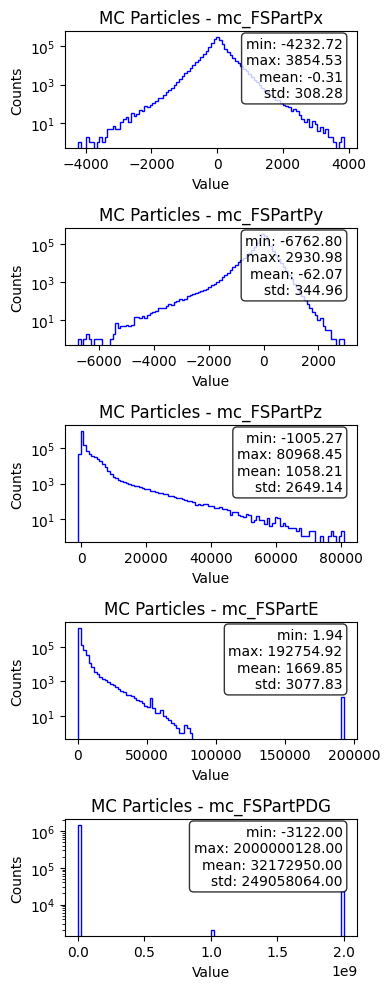

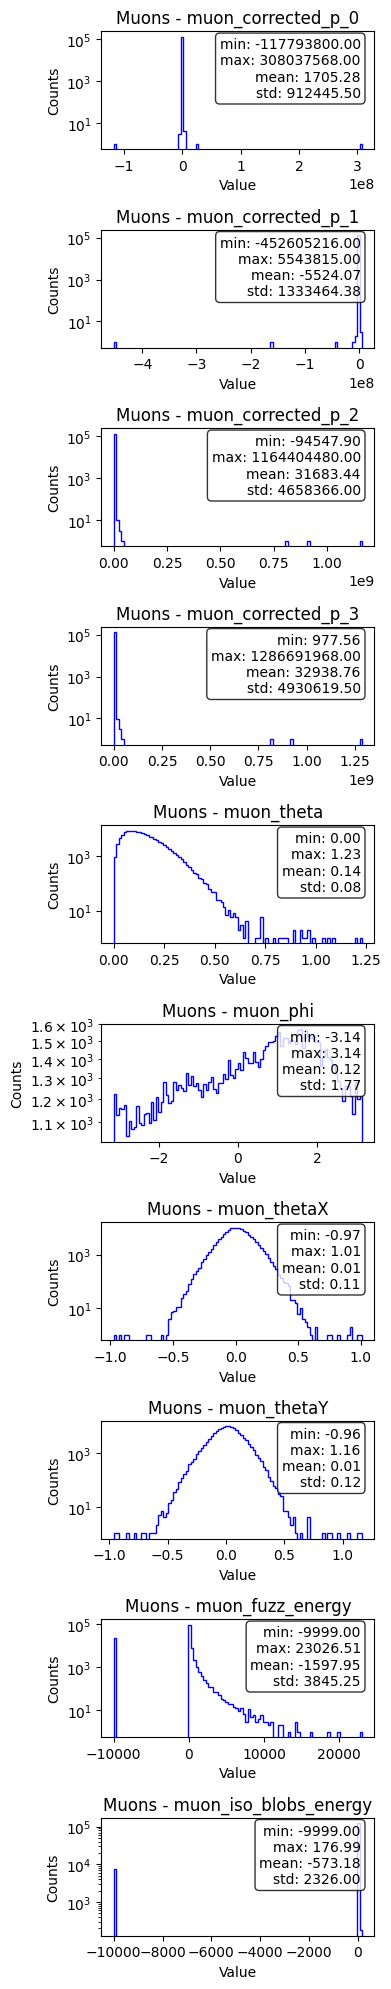

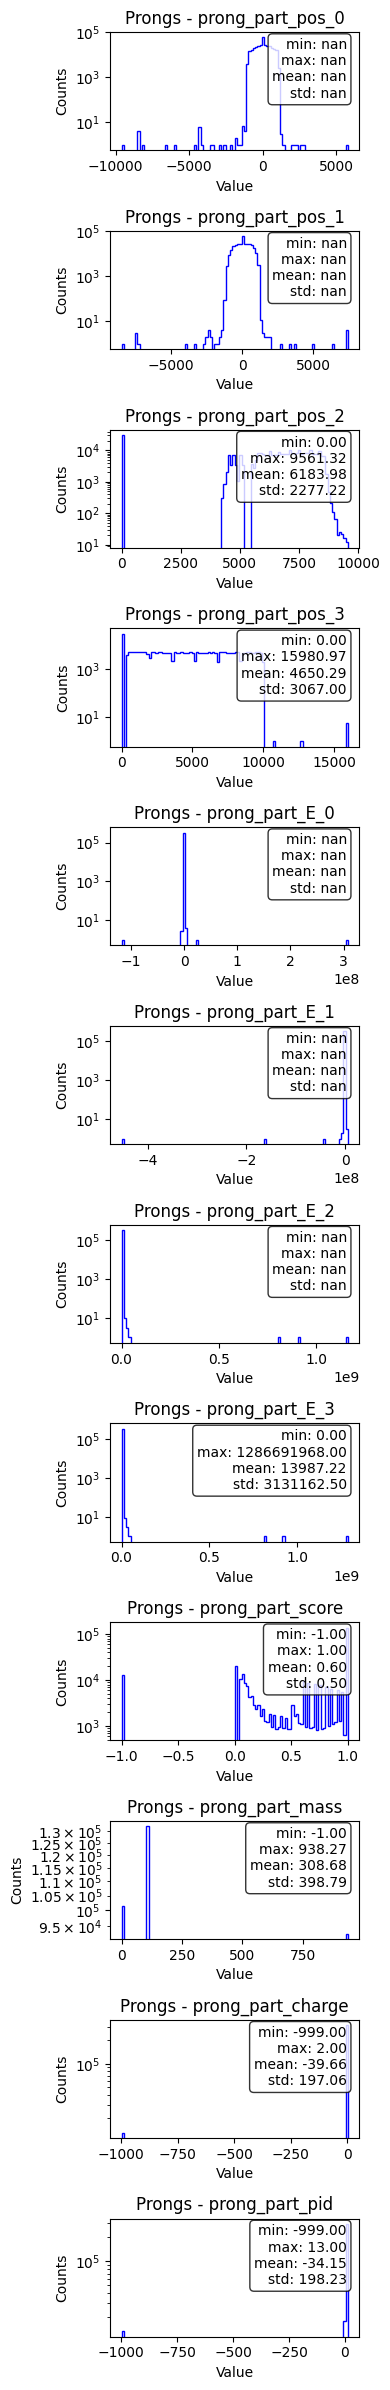

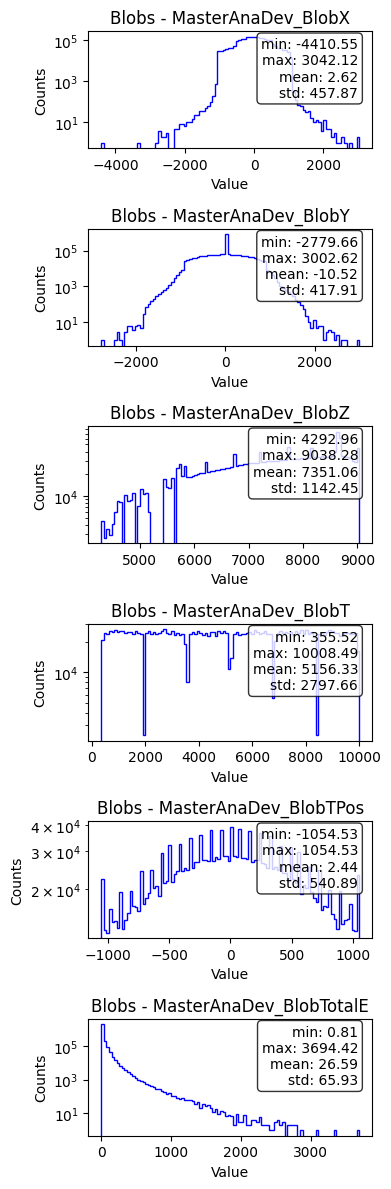

In [32]:
# Muon, MC_part, prong, and blob, make compact histograms of all the column values (all in one figure but separate plots stacked on top of each other).
# if column width > 1, make just a plot of the first component.
# Include some summary statistics (min, max, mean, std), and print them on the plots too. Make a separate figure for each of the four collections.

def plot_collection(collection: DenseCollection, collection_name: str):
    n_columns = len(collection.data[0])
    column_names = []
    for i in range(len(collection.keys)):
        if collection.column_widths[i] == 1:
            column_names.append(collection.keys[i])
        else:
            for j in range(collection.column_widths[i]):
                column_names.append(f"{collection.keys[i]}_{j}")
    fig, axes = plt.subplots(n_columns, 1, figsize=(4, 2 * n_columns))
    if n_columns == 1:
        axes = [axes]
    for i in range(n_columns):
        data_column = collection.data[:,i]
        # get column name + component (if applicable)
        column_name = column_names[i]
        axes[i].hist(data_column, bins=100, histtype='step', color='blue')
        axes[i].set_title(f"{collection_name} - {column_name}")
        axes[i].set_xlabel("Value")
        axes[i].set_ylabel("Counts")
        axes[i].set_yscale("log")
        # compute summary statistics
        col_min = np.min(data_column)
        if np.isnan(col_min):
            # print the data column if its nan
            print(f"Column {column_name} contains NaN values:", data_column)
            print("N of nan vals: ", np.isnan(data_column).sum())
        col_max = np.max(data_column)
        col_mean = np.mean(data_column)
        col_std = np.std(data_column)
        stats_text = f"min: {col_min:.2f}\nmax: {col_max:.2f}\nmean: {col_mean:.2f}\nstd: {col_std:.2f}"
        axes[i].text(0.95, 0.95, stats_text, transform=axes[i].transAxes,
                     verticalalignment='top', horizontalalignment='right',
                     bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    fig.tight_layout()
    fig.show()
plot_collection(mc_part, "MC Particles")
plot_collection(muon, "Muons")
plot_collection(prong, "Prongs")
plot_collection(blob, "Blobs")


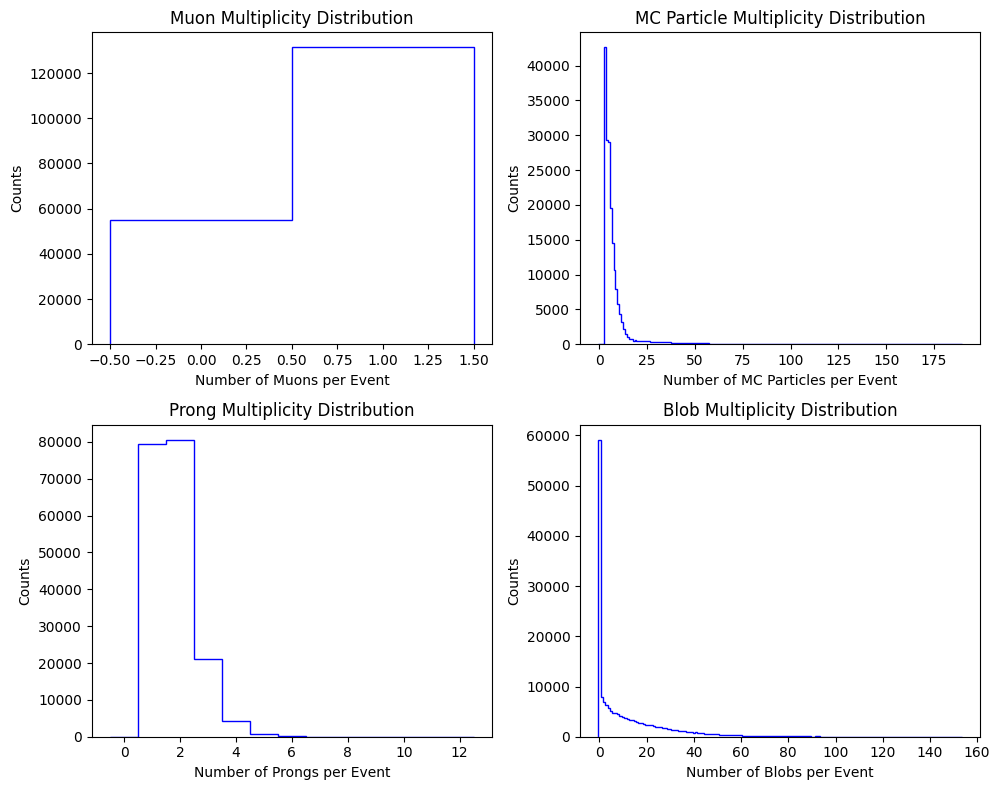

In [33]:
# plot histograms - distributions of N muons, M mc particles, N prongs, and N blobs per event.
fig, ax = plt.subplots(2, 2, figsize=(10, 8))
bins_muon = [0, 1, 2]
ax[0, 0].hist(muon.n, bins=bins_muon, histtype='step', color='blue', align='left', rwidth=0.5)
ax[0, 0].set_xlabel("Number of Muons per Event")
ax[0, 0].set_ylabel("Counts")
ax[0, 0].set_title("Muon Multiplicity Distribution")
bins_mc_part = np.arange(0, np.max(mc_part.n) + 2) - 0.5
ax[0, 1].hist(mc_part.n, bins=bins_mc_part, histtype='step', color='blue')
ax[0, 1].set_xlabel("Number of MC Particles per Event")
ax[0, 1].set_ylabel("Counts")
ax[0, 1].set_title("MC Particle Multiplicity Distribution")
bins_prong = np.arange(0, np.max(prong.n) + 2) - 0.5
ax[1, 0].hist(prong.n, bins=bins_prong, histtype='step', color='blue')
ax[1, 0].set_xlabel("Number of Prongs per Event")
ax[1, 0].set_ylabel("Counts")
ax[1, 0].set_title("Prong Multiplicity Distribution")
bins_blob = np.arange(0, np.max(blob.n) + 2) - 0.5
ax[1, 1].hist(blob.n, bins=bins_blob, histtype='step', color='blue')
ax[1, 1].set_xlabel("Number of Blobs per Event")
ax[1, 1].set_ylabel("Counts")
ax[1, 1].set_title("Blob Multiplicity Distribution")
fig.tight_layout()
fig.show()


In [34]:
# print statistics for the multiplicities of MC particles, prongs, blobs, muons (min, max, mean)
print(f"MC Particles: Min multiplicity: {np.min(mc_part.n)}, Max multiplicity: {np.max(mc_part.n)}, Mean multiplicity: {np.mean(mc_part.n)}")
print(f"Prongs: Min multiplicity: {np.min(prong.n)}, Max multiplicity: {np.max(prong.n)}, Mean multiplicity: {np.mean(prong.n)}")
print(f"Blobs: Min multiplicity: {np.min(blob.n)}, Max multiplicity: {np.max(blob.n)}, Mean multiplicity: {np.mean(blob.n)}")
print(f"Muons: Min multiplicity: {np.min(muon.n)}, Max multiplicity: {np.max(muon.n)}, Mean multiplicity: {np.mean(muon.n)}")


MC Particles: Min multiplicity: 2, Max multiplicity: 189, Mean multiplicity: 8.23340073697027
Prongs: Min multiplicity: 1, Max multiplicity: 12, Mean multiplicity: 1.7487811026662876
Blobs: Min multiplicity: 0, Max multiplicity: 153, Mean multiplicity: 12.451482790617844
Muons: Min multiplicity: 0, Max multiplicity: 1, Mean multiplicity: 0.7052333471001239


In [35]:
# print % with zero multiplicity for each of the collections
print("Percentage of events with zero multiplicity:")
print(f"MC Particles: {np.sum(mc_part.n == 0) / len(mc_part.n)}")
print(f"Prongs: {np.sum(prong.n == 0) / len(prong.n)}")
print(f"Blobs: {np.sum(blob.n == 0) / len(blob.n)}")
print(f"Muons: {np.sum(muon.n == 0) / len(muon.n)}")



Percentage of events with zero multiplicity:
MC Particles: 0.0
Prongs: 0.0
Blobs: 0.3172619462666073
Muons: 0.2947666528998761


In [36]:
master_ana_dev["prong_part_pos"].array()

<Array [[[-451, ..., 2.45e+03], ...], ...] type='186439 * var * var * float64'>

In [37]:
Erecoil = master_ana_dev["recoil_summed_energy"].array().to_numpy()[:, 0] / 1000 # Just pick the first element each time

In [40]:
# from the "muon"  collection, compute the energy of neutrino according to the CCQE formula
# formula: (2 Mp Emu - mmu^2) / (2(Mp-Emu + pmu cos(theta_mu)))
# first compute invariant mass of the four vectors as a sanity check
Emu = muon.data[:, 3] / 1000
pmu = np.linalg.norm(muon.data[:, 0:3], axis=1) / 1000
E_nu_formula = (2 * 0.9382720813505859 * Emu - 0.1056583745 * 0.1056583745) / (2 * (0.9382720813505859 - Emu + pmu * np.cos(muon.data[:, 4])))
#fig, ax = plt.subplots(1, 1, figsize=(10, 8))
#ax.hist(E_nu, bins=np.linspace(0, 10, 100), histtype='step', color='blue')
#ax.set_xlabel("Energy (GeV)")
#ax.set_ylabel("Counts")
#ax.set_title("Neutrino Energy Distribution")
#fig.show()



In [41]:
Emu

array([11.34486  ,  4.358424 ,  4.9631996, ...,  3.0214272,  6.800853 ,
        6.529032 ], dtype=float32)

In [42]:
current = master_ana_dev["mc_current"].array().to_numpy() # 1=CC, 2=NC
current.shape

(186439,)

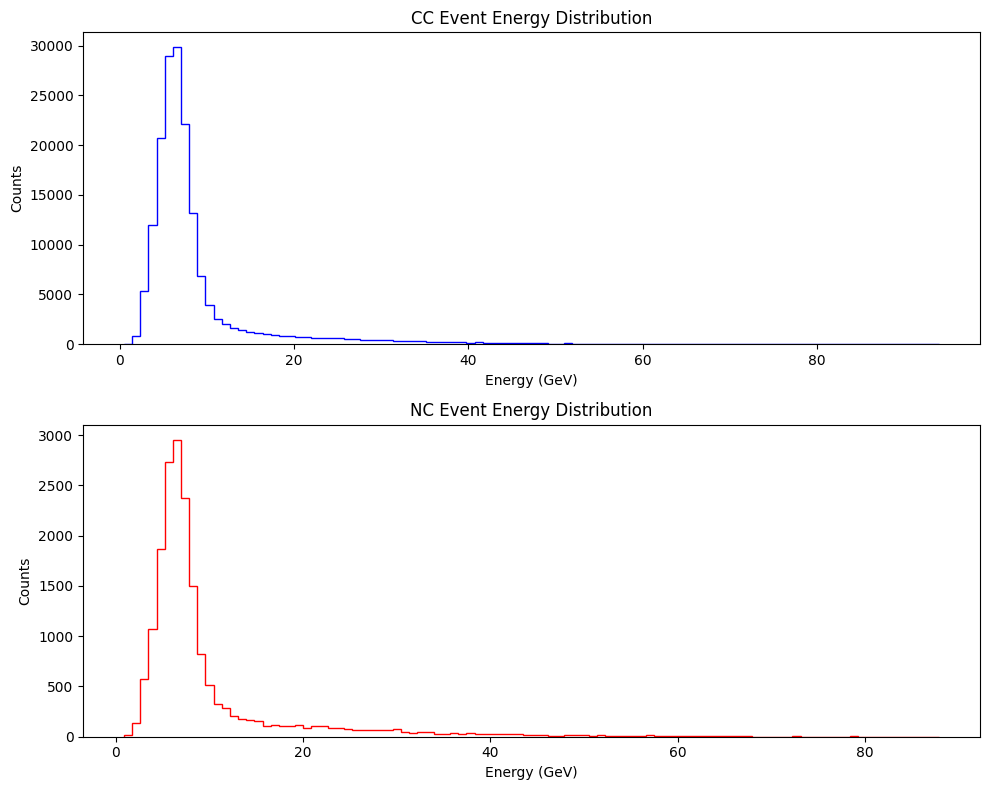

In [43]:

# Plot histograms of the CC and NC event energies
fig, ax = plt.subplots(2, 1, figsize=(10, 8))
ax[0].hist(master_ana_dev["mc_incomingE"].array().to_numpy()[current == 1]/1000, bins=100, histtype='step', color='blue')
ax[0].set_xlabel("Energy (GeV)")
ax[0].set_ylabel("Counts")
ax[0].set_title("CC Event Energy Distribution")
ax[1].hist(master_ana_dev["mc_incomingE"].array().to_numpy()[current == 2]/1000, bins=100, histtype='step', color='red')
ax[1].set_xlabel("Energy (GeV)")
ax[1].set_ylabel("Counts")
ax[1].set_title("NC Event Energy Distribution")
fig.tight_layout()
fig.show()

In [44]:
# count number of CC and NC events
n_cc = np.sum(current == 1)
n_nc = np.sum(current == 2)
print(f"Number of CC events: {n_cc}")
print(f"Number of NC events: {n_nc}")
print(f"Percentage of CC events: {n_cc / (n_cc + n_nc)}")
print(f"Percentage of NC events: {n_nc / (n_cc + n_nc)}")
# plot histograms of the CC and NC event energies



Number of CC events: 168283
Number of NC events: 18154
Percentage of CC events: 0.9026266245434115
Percentage of NC events: 0.09737337545658856


In [45]:
a = master_ana_dev["truth_reco_has_muon"].array().to_numpy()
b = master_ana_dev["muon_corrected_p"].array().to_numpy()[:, 0] == -999
c = current == 1 # is CC

In [46]:
# make a sort of confusion matrix of a and b
confusion_matrix = np.zeros((2, 2))
for i in range(len(a)):
    if a[i] == 1:
        if b[i] == 1:
            confusion_matrix[0, 0] += 1
        else:
            confusion_matrix[0, 1] += 1
    else:
        if b[i] == 1:
            confusion_matrix[1, 0] += 1
        else:
            confusion_matrix[1, 1] += 1
confusion_matrix

array([[   200., 131483.],
       [ 54756.,      0.]])

In [47]:
# Confusion matrix of a and c
confusion_matrix = np.zeros((2, 2))
for i in range(len(a)):
    if a[i] == 1:
        if c[i] == 1:
            confusion_matrix[0, 0] += 1
        else:
            confusion_matrix[0, 1] += 1
    else:
        if c[i] == 1:
            confusion_matrix[1, 0] += 1
        else:
            confusion_matrix[1, 1] += 1
confusion_matrix

array([[131491.,    192.],
       [ 36792.,  17964.]])

In [48]:
# mc_primaryLepton
lepton = master_ana_dev["mc_primaryLepton"].array().to_numpy()
# unique values
np.unique(lepton)

array([-14, -13, -12, -11,  11,  12,  13,  14], dtype=int32)

In [49]:
# Get counts of each unique value of primary lepton
np.unique(lepton, return_counts=True)

(array([-14, -13, -12, -11,  11,  12,  13,  14], dtype=int32),
 array([   361,   4330,     10,     97,   1703,    226, 162164,  17548]))

In [50]:
master_ana_dev["MasterAnaDev_enu_muon"].array()

<Array [1.24e+04, -1e+04, ..., -1e+04, -1e+04] type='186439 * float64'>

In [51]:
master_ana_dev["MasterAnaDev_enu_proton"].array()

<Array [2.34e+03, -1e+04, ..., -1e+04, -1e+04] type='186439 * float64'>

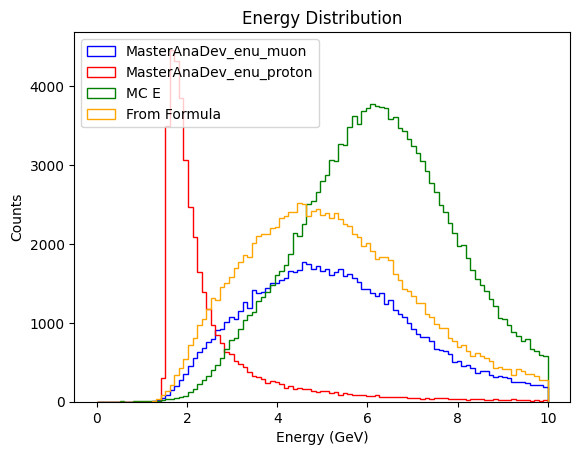

In [69]:
# plot distribution of enu_muon and enu_proton and mc_incomingE (all / 1000)
bins = np.linspace(0, 10, 100)
plt.hist(master_ana_dev["MasterAnaDev_enu_muon"].array().to_numpy() / 1000, bins=bins, histtype='step', color='blue', label='MasterAnaDev_enu_muon')
plt.hist(master_ana_dev["MasterAnaDev_enu_proton"].array().to_numpy() / 1000, bins=bins, histtype='step', color='red', label='MasterAnaDev_enu_proton')
plt.hist(master_ana_dev["mc_incomingE"].array().to_numpy() / 1000, bins=bins, histtype='step', color='green', label='MC E')
Emu = muon.data[:, 3] / 1000
pmu = np.linalg.norm(muon.data[:, 0:3], axis=1) / 1000
mu_theta_cos = muon.data[:, 2] / np.linalg.norm(muon.data[:, 0:3], axis=1)

E_nu_formula = (2 * 0.9382720813505859 * Emu - 0.1056583745 * 0.1056583745) / (2 * (0.9382720813505859 - Emu + pmu * mu_theta_cos))
plt.hist(E_nu_formula, bins=bins, histtype='step', color='orange', label='From Formula')
plt.xlabel("Energy (GeV)")
plt.ylabel("Counts")
plt.legend()
plt.title("Energy Distribution")
plt.show()


In [70]:
counts = master_ana_dev["MasterAnaDev_enu_muon"].array().to_numpy() / 1000

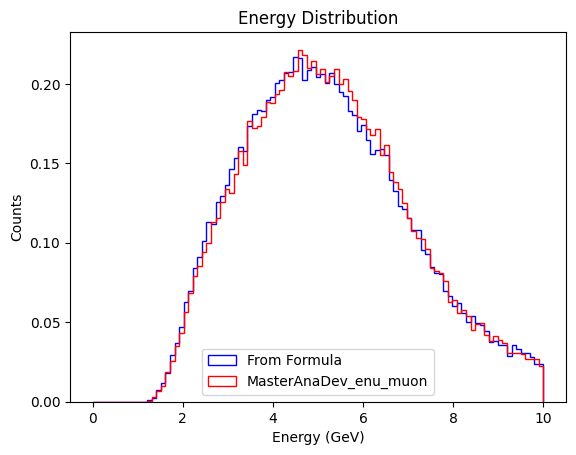

In [71]:
# normalized E_nu_formula and from MasterAnaDev_enu_muon
fig, ax = plt.subplots()
bins = np.linspace(0, 10, 100)
ax.hist(E_nu_formula, bins=bins, histtype='step', color='blue', label='From Formula', density=True)
ax.hist(counts, bins=bins, histtype='step', color='red', label='MasterAnaDev_enu_muon', density=True)
ax.set_xlabel("Energy (GeV)")
ax.set_ylabel("Counts")
ax.legend()
ax.set_title("Energy Distribution")
fig.show()

In [ ]:
# check how many events have e from muon > 0 and e from proton > 0 and all intersections (basically a 2x2 conf mat)
muon_mask = master_ana_dev["MasterAnaDev_enu_muon"].array().to_numpy() > 0
proton_mask = master_ana_dev["MasterAnaDev_enu_proton"].array().to_numpy() > 0
confusion_matrix = np.zeros((2, 2))
for i in range(len(muon_mask)):
    if muon_mask[i] == 1:
        if proton_mask[i] == 1:
            confusion_matrix[0, 0] += 1
        else:
            confusion_matrix[0, 1] += 1
    else:
        if proton_mask[i] == 1:
            confusion_matrix[1, 0] += 1
        else:
            confusion_matrix[1, 1] += 1

In [ ]:
confusion_matrix

array([[40740., 49605.],
       [  193., 95901.]])

/tmp/ipykernel_1361/309436863.py:25: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax[1].legend()


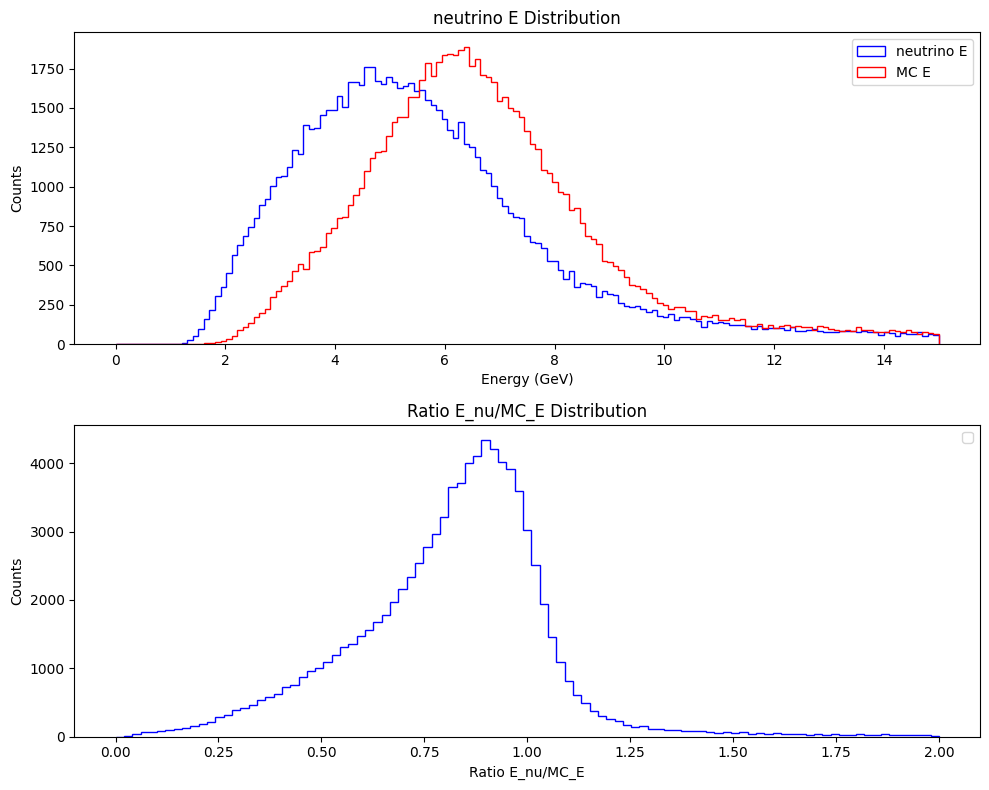

In [58]:
# for E nu, use E from muon if available (>0). Otherwise, use E from proton.
# if not available, skip the event.
MC_E = master_ana_dev["mc_incomingE"].array().to_numpy() / 1000
E_from_muon = master_ana_dev["MasterAnaDev_enu_muon"].array().to_numpy() / 1000
E_from_proton = master_ana_dev["MasterAnaDev_enu_proton"].array().to_numpy() / 1000
E_nu = np.where(E_from_muon > 0, E_from_muon, E_from_proton)
E_nu_mask = E_nu > 0
E_nu = E_nu[E_nu_mask]
MC_E = MC_E[E_nu_mask]
ratio_use_muon_only = E_nu/MC_E
fig, ax = plt.subplots(2, 1, figsize=(10, 8))
# on thop, plot hist of E_nu and MC_E. On botom, plot histogram of ratio E_nu/MC_E (should be centered around 1)
bins = np.linspace(0, 15, 150)
bins_ratio = np.linspace(0, 2, 100)
ax[0].hist(E_nu, bins=bins, histtype='step', color='blue', label='neutrino E')
ax[0].hist(MC_E, bins=bins, histtype='step', color='red', label='MC E')
ax[0].set_xlabel("Energy (GeV)")
ax[0].set_ylabel("Counts")
ax[0].set_title("neutrino E Distribution")
ax[0].legend()
ax[1].hist(E_nu/MC_E, bins=bins_ratio, histtype='step', color='blue')
ax[1].set_xlabel("Ratio E_nu/MC_E")
ax[1].set_ylabel("Counts")
ax[1].set_title("Ratio E_nu/MC_E Distribution")
ax[1].legend()
fig.tight_layout()
fig.show()

/tmp/ipykernel_1634/1791207600.py:24: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax[1].legend()


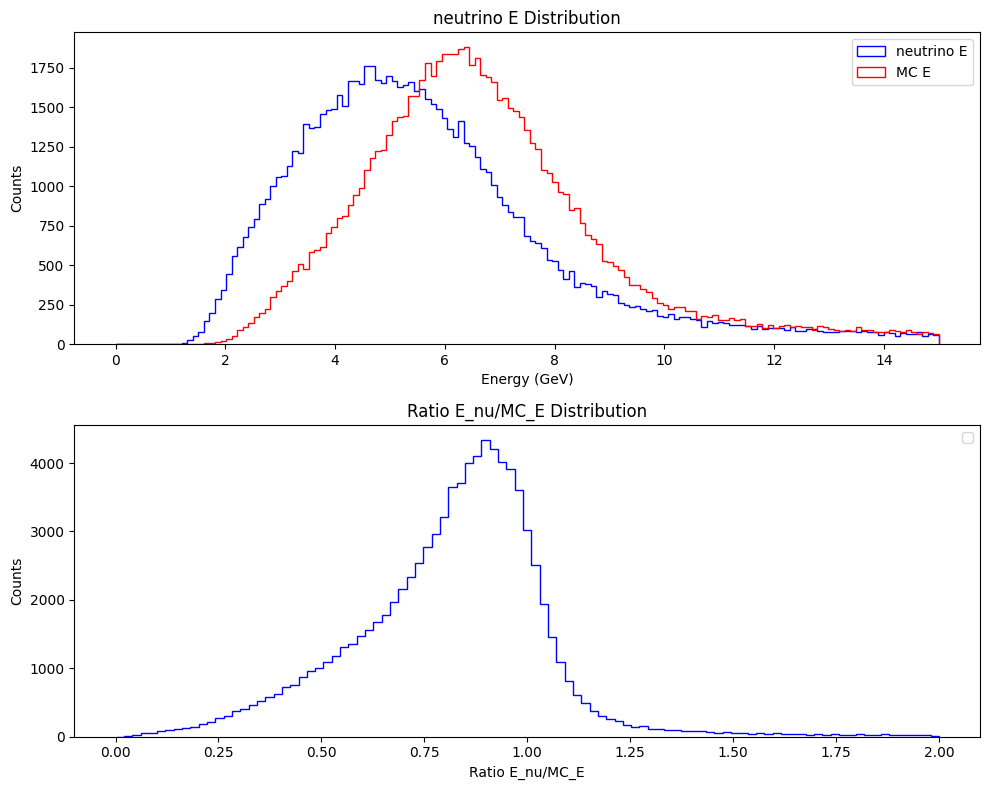

In [ ]:
# for E nu, use E from muon if available (>0). Otherwise, use E from proton.
# if not available, skip the event.
MC_E = master_ana_dev["mc_incomingE"].array().to_numpy() / 1000
E_from_muon = master_ana_dev["MasterAnaDev_enu_muon"].array().to_numpy() / 1000
E_from_proton = master_ana_dev["MasterAnaDev_enu_proton"].array().to_numpy() / 1000
E_nu = E_from_muon
E_nu_mask = E_nu > 0
E_nu = E_nu[E_nu_mask]
MC_E = MC_E[E_nu_mask]
fig, ax = plt.subplots(2, 1, figsize=(10, 8))
# on thop, plot hist of E_nu and MC_E. On botom, plot histogram of ratio E_nu/MC_E (should be centered around 1)
bins = np.linspace(0, 15, 150)
bins_ratio = np.linspace(0, 2, 100)
ax[0].hist(E_nu, bins=bins, histtype='step', color='blue', label='neutrino E')
ax[0].hist(MC_E, bins=bins, histtype='step', color='red', label='MC E')
ax[0].set_xlabel("Energy (GeV)")
ax[0].set_ylabel("Counts")
ax[0].set_title("neutrino E Distribution")
ax[0].legend()
ax[1].hist(E_nu/MC_E, bins=bins_ratio, histtype='step', color='blue')
ax[1].set_xlabel("Ratio E_nu/MC_E")
ax[1].set_ylabel("Counts")
ax[1].set_title("Ratio E_nu/MC_E Distribution")
ax[1].legend()
fig.tight_layout()
fig.show()

/tmp/ipykernel_1634/2371775737.py:24: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax[1].legend()


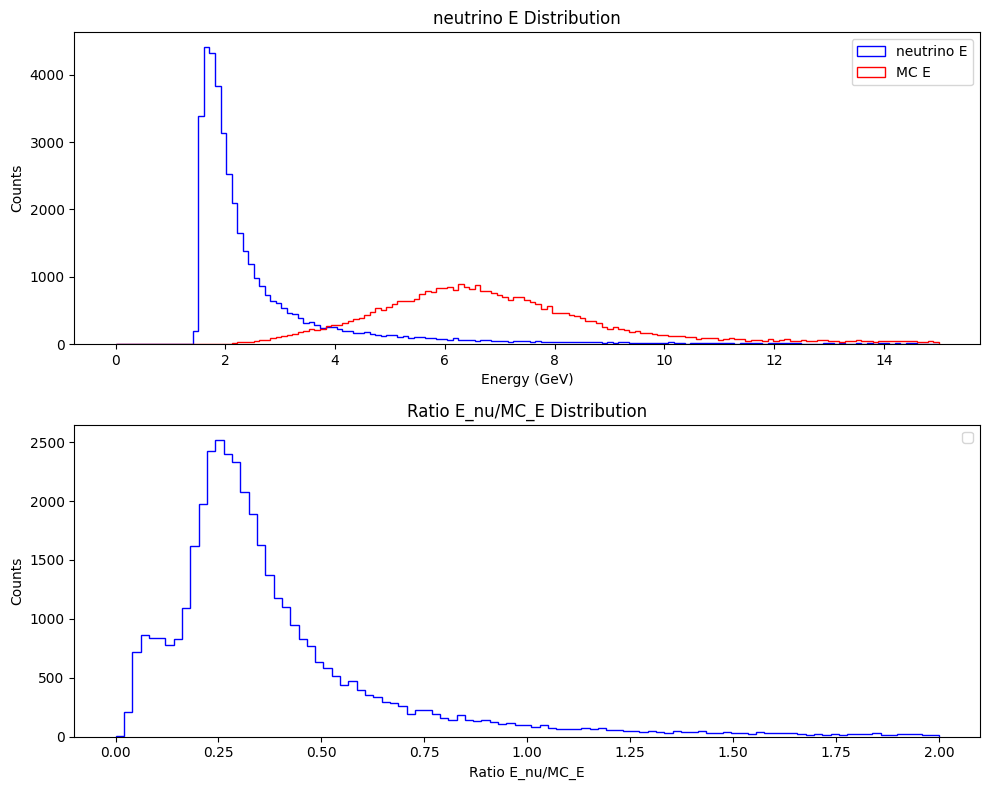

In [ ]:
# for E nu, use E from muon if available (>0). Otherwise, use E from proton.
# if not available, skip the event.
MC_E = master_ana_dev["mc_incomingE"].array().to_numpy() / 1000
E_from_muon = master_ana_dev["MasterAnaDev_enu_muon"].array().to_numpy() / 1000
E_from_proton = master_ana_dev["MasterAnaDev_enu_proton"].array().to_numpy() / 1000
E_nu = E_from_proton
E_nu_mask = E_nu > 0
E_nu = E_nu[E_nu_mask]
MC_E = MC_E[E_nu_mask]
fig, ax = plt.subplots(2, 1, figsize=(10, 8))
# on thop, plot hist of E_nu and MC_E. On botom, plot histogram of ratio E_nu/MC_E (should be centered around 1)
bins = np.linspace(0, 15, 150)
bins_ratio = np.linspace(0, 2, 100)
ax[0].hist(E_nu, bins=bins, histtype='step', color='blue', label='neutrino E')
ax[0].hist(MC_E, bins=bins, histtype='step', color='red', label='MC E')
ax[0].set_xlabel("Energy (GeV)")
ax[0].set_ylabel("Counts")
ax[0].set_title("neutrino E Distribution")
ax[0].legend()
ax[1].hist(E_nu/MC_E, bins=bins_ratio, histtype='step', color='blue')
ax[1].set_xlabel("Ratio E_nu/MC_E")
ax[1].set_ylabel("Counts")
ax[1].set_title("Ratio E_nu/MC_E Distribution")
ax[1].legend()
fig.tight_layout()
fig.show()

/tmp/ipykernel_1361/3728430595.py:25: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax[1].legend()


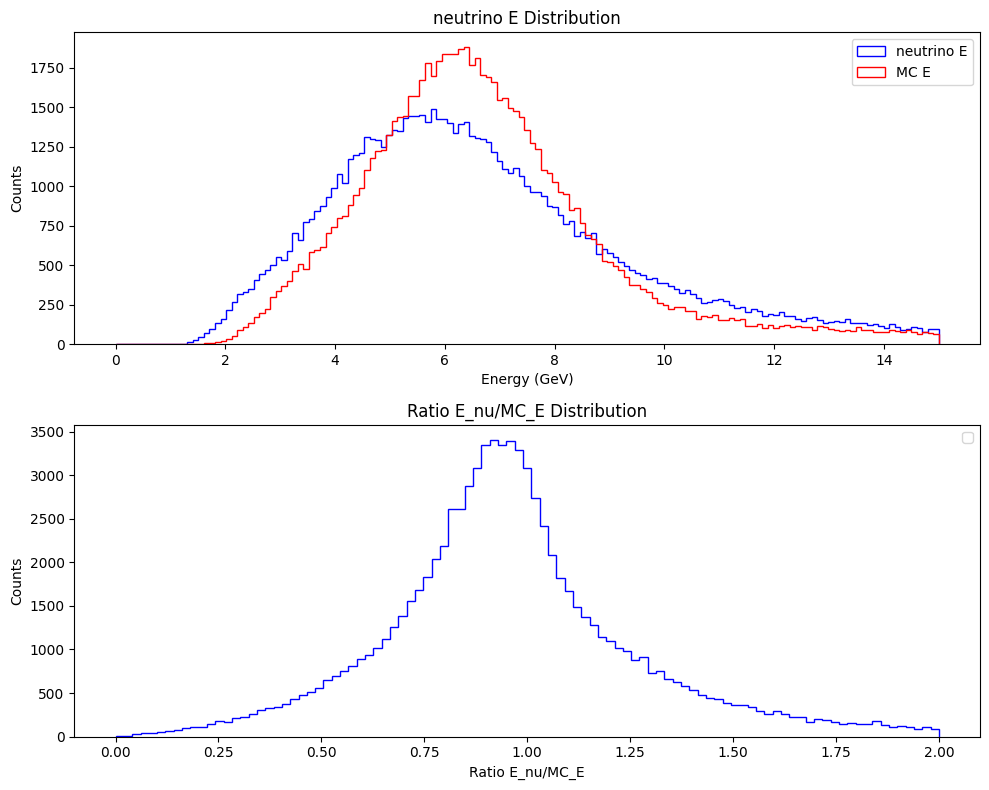

In [56]:
# for E nu, use E from muon if available (>0). Otherwise, use E from proton.
# if not available, skip the event.
MC_E = master_ana_dev["mc_incomingE"].array().to_numpy() / 1000
E_from_muon = master_ana_dev["MasterAnaDev_enu_muon"].array().to_numpy() / 1000
E_from_proton = master_ana_dev["MasterAnaDev_enu_proton"].array().to_numpy() / 1000
E_nu = E_from_muon + np.where(E_from_proton > 0, E_from_proton, 0)
E_nu_mask = E_nu > 0
E_nu = E_nu[E_nu_mask]
MC_E = MC_E[E_nu_mask]
ratio_use_muon_and_proton = E_nu/MC_E
fig, ax = plt.subplots(2, 1, figsize=(10, 8))
# on thop, plot hist of E_nu and MC_E. On botom, plot histogram of ratio E_nu/MC_E (should be centered around 1)
bins = np.linspace(0, 15, 150)
bins_ratio = np.linspace(0, 2, 100)
ax[0].hist(E_nu, bins=bins, histtype='step', color='blue', label='neutrino E')
ax[0].hist(MC_E, bins=bins, histtype='step', color='red', label='MC E')
ax[0].set_xlabel("Energy (GeV)")
ax[0].set_ylabel("Counts")
ax[0].set_title("neutrino E Distribution")
ax[0].legend()
ax[1].hist(E_nu/MC_E, bins=bins_ratio, histtype='step', color='blue')
ax[1].set_xlabel("Ratio E_nu/MC_E")
ax[1].set_ylabel("Counts")
ax[1].set_title("Ratio E_nu/MC_E Distribution")
ax[1].legend()
fig.tight_layout()
fig.show()

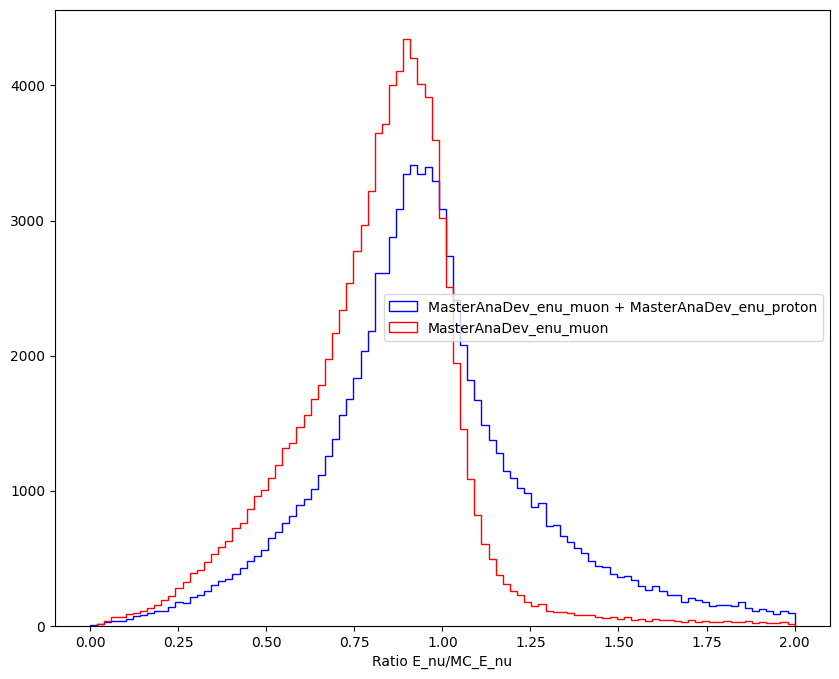

In [59]:
fig, ax = plt.subplots(1, 1, figsize=(10, 8))
ax.hist(ratio_use_muon_and_proton, bins=bins_ratio, histtype='step', color='blue', label='MasterAnaDev_enu_muon + MasterAnaDev_enu_proton')
ax.hist(ratio_use_muon_only, bins=bins_ratio, histtype='step', color='red', label='MasterAnaDev_enu_muon')
ax.legend()
ax.set_xlabel("Ratio E_nu/MC_E_nu")
fig.show()

In [ ]:
np.unique(mc_part.data[:, -1].astype(int))

array([     -3122,      -2212,      -2112,       -321,       -311,
             -211,        -16,        -14,        -13,        -12,
              -11,         11,         12,         13,         14,
               16,         22,        111,        130,        211,
              311,        321,       2112,       2212,       3112,
             3122,       3212,       3222, 1000060096, 1000070144,
       1000080128, 1000130240, 1000220480, 1000260544, 1000822080,
       2000000128])

In [ ]:
mc_part.bounds

array([      0,      11,      28, ..., 1535016, 1535024, 1535027],
      dtype=int32)

In [ ]:
mc_part.data[0:11, -1]

array([ -13., 2112., 2212., -211.,  111., 2212., 2212., 2212., 2112.,
       -211., 2112.], dtype=float32)

In [ ]:
master_ana_dev["mc_incomingE"].array().to_numpy()


array([16958.06921095,  5057.47995483,  5319.70144219, ...,
        3963.06455604,  8009.65274946,  7043.04398091])

In [ ]:
# Get the energy of the muon from mc_part as a sanity check (E of all particles - masses of particles)
mc_part.keys
evt_idx = -4


data = mc_part.data[mc_part.bounds[evt_idx]:mc_part.bounds[evt_idx+1]]
mass = np.sqrt(data[:, 3]**2 - data[:, 0]**2 - data[:, 1]**2 - data[:, 2]**2)
np.sum(data[:, 3] - mass)

/tmp/ipykernel_1634/4124960621.py:7: RuntimeWarning: invalid value encountered in sqrt
  mass = np.sqrt(data[:, 3]**2 - data[:, 0]**2 - data[:, 1]**2 - data[:, 2]**2)


nan

In [ ]:
data[:, 3]**2- data[:, 0]**2 - data[:, 1]**2 - data[:, 2]**2

array([-5.0000000e-01,  8.8035025e+05,  1.9479791e+04,  1.8219562e+04],
      dtype=float32)

In [62]:
# compute the neutrino energy from mc particles
n_events = mc_part.n.shape[0]
E_nu = np.zeros(n_events)
for i in range(n_events):
    data = mc_part.data[mc_part.bounds[i]:mc_part.bounds[i+1]]
    E_particles = data[:, 3]
    p_size_particles = np.linalg.norm(data[:, 0:3], axis=1)
    mass = np.sqrt(E_particles**2 - p_size_particles**2)
    # replace nan with 0
    mass[np.isnan(mass)] = 0
    E_nu[i] = np.sum(E_particles - mass)




/tmp/ipykernel_1361/1267430897.py:8: RuntimeWarning: invalid value encountered in sqrt
  mass = np.sqrt(E_particles**2 - p_size_particles**2)


In [63]:
E_nu_true = master_ana_dev["mc_incomingE"].array().to_numpy()
ratio_ideal_reconstruction = E_nu  / E_nu_true

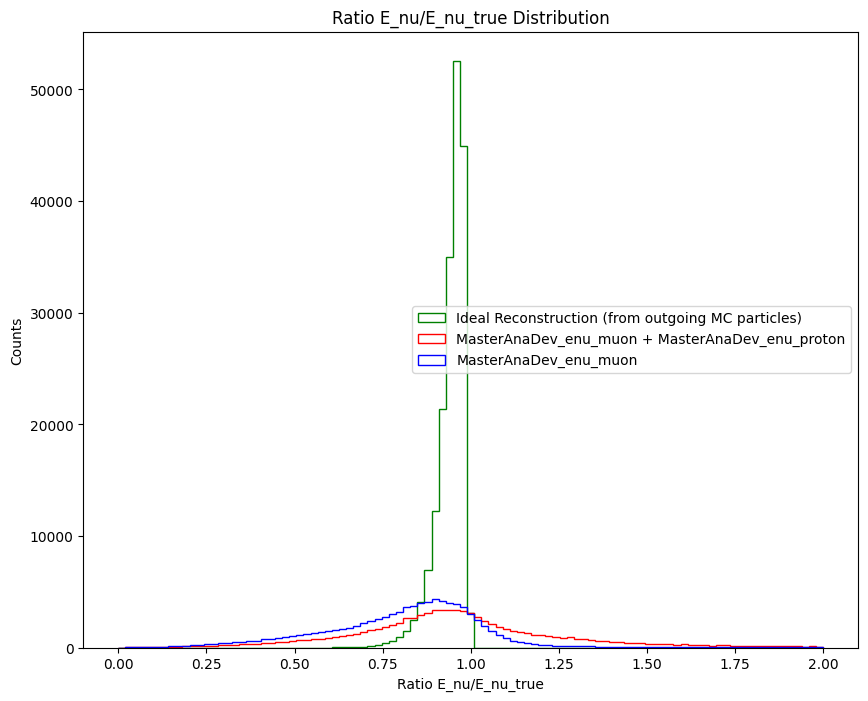

In [64]:
fig, ax = plt.subplots(1, 1, figsize=(10, 8))
bins = np.linspace(0, 2, 100)
ax.hist(ratio_ideal_reconstruction, bins=bins, histtype='step', color='green', label='Ideal Reconstruction (from outgoing MC particles)')
ax.hist(ratio_use_muon_and_proton, bins=bins, histtype='step', color='red', label='MasterAnaDev_enu_muon + MasterAnaDev_enu_proton')
ax.hist(ratio_use_muon_only, bins=bins, histtype='step', color='blue', label='MasterAnaDev_enu_muon')
ax.set_xlabel("Ratio E_nu/E_nu_true")
ax.set_ylabel("Counts")
ax.set_title("Ratio E_nu/E_nu_true Distribution")
ax.legend()
fig.show()


In [ ]:
E_recoil = master_ana_dev['MasterAnaDev_hadron_recoil'].array().to_numpy()
E_recoil = np.where(E_recoil >= 0, E_recoil, 0)
E_recoil_CCinc = master_ana_dev['MasterAnaDev_hadron_recoil_CCInc'].array().to_numpy()
E_recoil_CCinc = np.where(E_recoil_CCinc >= 0, E_recoil_CCinc, 0)

array([11327.66922103, -9999.        ,  4963.19969681, ...,
         400.7244185 , -9999.        , -9999.        ])

In [68]:
E_mu = master_ana_dev["muon_corrected_p"].array().to_numpy()[:, 3]
E_mu = np.where(E_mu >= 0, E_mu, 0)
E_nu_muon_recoil = (E_mu + E_recoil) / 1000

In [78]:
np.where(E_mu==0)[0][3]

16

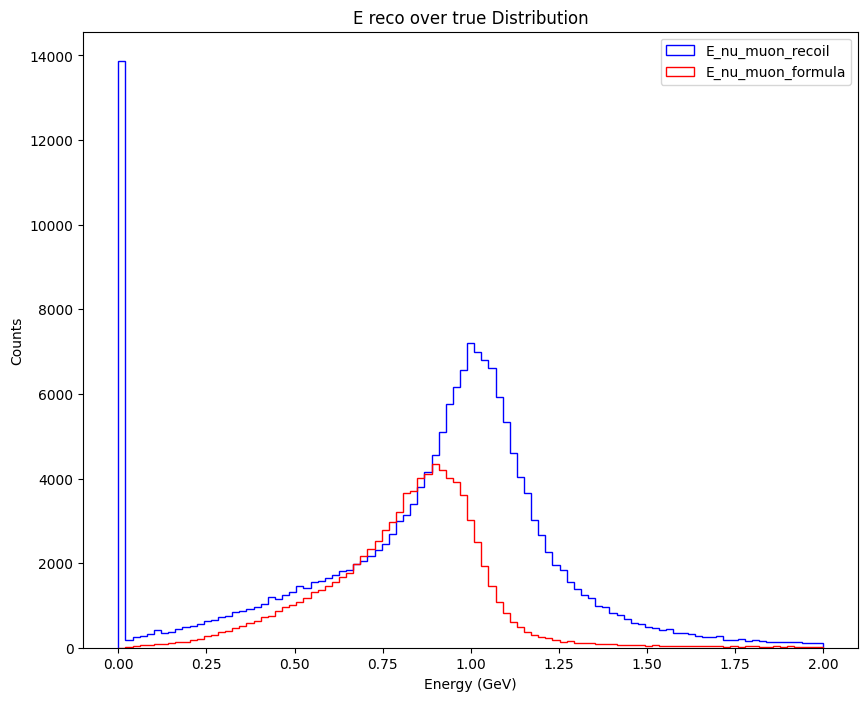

In [71]:
E_nu_muon_formula = master_ana_dev["MasterAnaDev_enu_muon"].array().to_numpy() / 1000
E_nu_true = master_ana_dev["mc_incomingE"].array().to_numpy() / 1000
fig, ax = plt.subplots(1, 1, figsize=(10, 8))
bins = np.linspace(0, 2, 100)
ax.hist(E_nu_muon_recoil / E_nu_true, bins=bins, histtype='step', color='blue', label='E_nu_muon_recoil')
ax.hist(E_nu_muon_formula / E_nu_true, bins=bins, histtype='step', color='red', label='E_nu_muon_formula')
ax.set_xlabel("Energy (GeV)")
ax.set_ylabel("Counts")
ax.legend()
ax.set_title("E reco over true Distribution")
fig.show()

In [40]:
E_sum_blob_per_event = np.zeros(blob.n.shape[0])
E_sum_prong_per_event = np.zeros(prong.n.shape[0])
for i in range(blob.n.shape[0]):
    E_sum_blob_per_event[i] = np.sum(blob.data[blob.bounds[i]:blob.bounds[i+1], 5])
    E_sum_prong_per_event[i] = np.sum(prong.data[prong.bounds[i]:prong.bounds[i+1], ])
E_sum_blob_per_event[:10], E_sum_prong_per_event[:10]


(array([311.93551636,   0.        ,   8.81560135,   0.        ,
         17.75290489, 222.90682983, 368.35882568, 153.00085449,
        961.40026855,   0.        ]),
 array([38244.6015625 , 21866.12304688, 37524.48046875, 28091.79296875,
        20353.30078125, 76065.7578125 , 26516.90234375, 17832.1796875 ,
        40185.24609375, 17821.10351562]))

NameError: name 'E_mu' is not defined

array([16.95806921,  5.05747995,  5.31970144, ...,  3.96306456,
        8.00965275,  7.04304398])